In [2]:
import pandas as pd
import numpy as np
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
import pandas as pd

df = pd.read_csv(
    r"c:\Users\dell\Documents\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

In [5]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [6]:
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month

In [7]:
monthly_sales['Sales_lag_1'] = monthly_sales['Sales'].shift(1)
monthly_sales['Sales_lag_3'] = monthly_sales['Sales'].shift(3)
monthly_sales['Sales_lag_6'] = monthly_sales['Sales'].shift(6)

monthly_sales.dropna(inplace=True)

In [8]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size]
test = monthly_sales.iloc[train_size:]

X_train = train.drop(['Sales', 'Order Date'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Sales', 'Order Date'], axis=1)
y_test = test['Sales']

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13712.424938680282
RMSE: 16257.742213535776


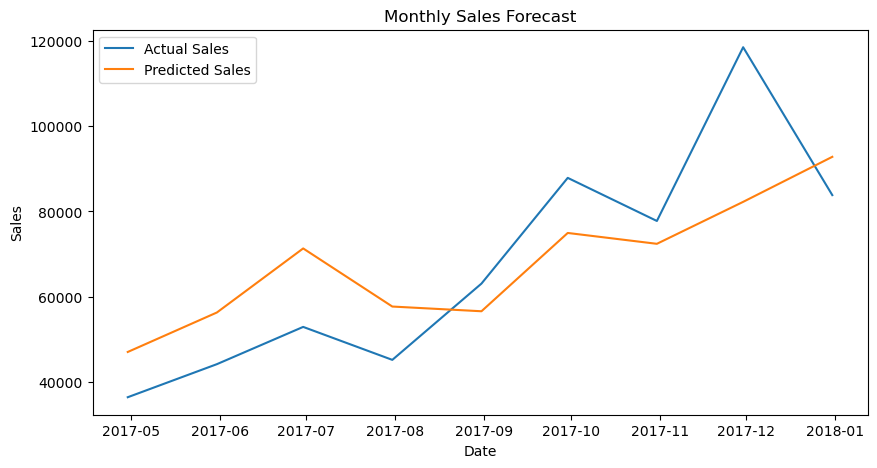

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test['Order Date'], y_test, label='Actual Sales')
plt.plot(test['Order Date'], y_pred, label='Predicted Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Sales Forecast")
plt.legend()
plt.show()

In [13]:
import pickle

with open("../models/sales_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved as sales_model.pkl")

Model saved as sales_model.pkl
